# Notebook 3: Estadística inferencial con Python



## Preparación del ambiente de trabajo

Primero importamos las librerías que se usarán en el notebook. Se utiliza `numpy` para simulación y cálculos numéricos, `pandas` para organizar resultados, `matplotlib` para visualización y `scipy.stats` para cuantiles de distribuciones como la normal y la t de Student.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Semilla para que los resultados sean reproducibles
rng = np.random.default_rng(123)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# 1. Estimadores

## 1.1 Definición de estimador

De acuerdo con el enfoque usual en estadística matemática, un **estimador** es una función de la muestra aleatoria que se usa para aproximar un parámetro desconocido de una población.

Si $X_1, X_2, \ldots, X_n$ es una muestra aleatoria y $\theta$ es un parámetro desconocido, un estimador de $\theta$ se suele escribir como:

$$
\hat{\theta}=g(X_1,X_2,\ldots,X_n).
$$

La diferencia entre **estimador** y **estimación** es importante:

- El **estimador** es la regla o fórmula general.
- La **estimación** es el valor numérico obtenido al aplicar esa regla a una muestra específica.

Por ejemplo, si se quiere estimar la media poblacional $\mu$, un estimador natural es la media muestral:

$$
\bar{X}=\frac{1}{n}\sum_{i=1}^{n}X_i.
$$

En palabras simples: un estimador toma la información de la muestra y la resume en un valor que pretende representar un parámetro poblacional.

### Ejemplo inicial: estimar una media poblacional

Supongamos que se toma una muestra de tiempos de atención, en minutos, y se desea estimar el tiempo promedio poblacional. Como no se observa a toda la población, usamos la media muestral como estimador.

In [24]:
# Datos de ejemplo: tiempos de atención en minutos
muestra_tiempos = np.array([12, 15, 11, 18, 14, 16, 13, 17, 15, 14])

# Estimador de la media poblacional: media muestral
media_muestral = np.mean(muestra_tiempos)

# Estimador insesgado de la varianza poblacional: varianza muestral con ddof=1
varianza_muestral = np.var(muestra_tiempos, ddof=1)

resumen_estimadores = pd.DataFrame({
    "Cantidad estimada": ["Media poblacional", "Varianza poblacional"],
    "Estimador usado": ["Media muestral", "Varianza muestral insesgada"],
    "Valor estimado": [media_muestral, varianza_muestral]
})

resumen_estimadores

,Cantidad estimada,Estimador usado,Valor estimado
0,Media poblacional,Media muestral,14.500000
1,Varianza poblacional,Varianza muestral insesgada,4.722222


**Interpretación.** La media muestral obtenida es una estimación del tiempo promedio de atención de toda la población. No afirma que el verdadero promedio sea exactamente ese valor, sino que ese es el mejor resumen disponible con la información muestral observada.

## 1.2 Método de momentos

El **método de momentos** consiste en igualar momentos teóricos de la distribución con momentos calculados a partir de la muestra.

Si una distribución depende de un parámetro $\theta$ y se sabe que su esperanza teórica es una función de ese parámetro, por ejemplo:

$$
\mathbb{E}(X)=h(\theta),
$$

entonces se iguala con la media muestral:

$$
\bar{X}=h(\theta),
$$

y se despeja $\theta$. El resultado es el estimador por momentos.

La interpretación es directa: se elige el valor del parámetro que hace que el comportamiento teórico de la distribución se parezca al comportamiento observado en la muestra.

### Ejemplo por método de momentos: distribución uniforme continua

Supongamos que $X\sim U(0,\theta)$ y que $\theta$ es desconocido. Para esta distribución:

$$
\mathbb{E}(X)=\frac{\theta}{2}.
$$

Igualamos la esperanza teórica con la media muestral:

$$
\bar{X}=\frac{\theta}{2}.
$$

Despejando:

$$
\hat{\theta}_{MM}=2\bar{X}.
$$

Esto significa que usamos el promedio observado para estimar el extremo superior del intervalo donde se distribuyen los datos.

In [25]:
# Parámetro real usado solamente para simular los datos
theta_real = 10
n = 50

# Simulamos una muestra de una Uniforme(0, theta_real)
muestra_uniforme = rng.uniform(0, theta_real, size=n)

# Estimador por método de momentos para theta
media_uniforme = np.mean(muestra_uniforme)
theta_mm = 2 * media_uniforme

print(f"Media muestral: {media_uniforme:.4f}")
print(f"Estimador por método de momentos de theta: {theta_mm:.4f}")
print(f"Valor real de theta usado en la simulación: {theta_real}")

Media muestral: 4.9245
Estimador por método de momentos de theta: 9.8490
Valor real de theta usado en la simulación: 10


La siguiente gráfica compara los datos simulados con el valor real de $\theta$ y con la estimación obtenida por método de momentos.

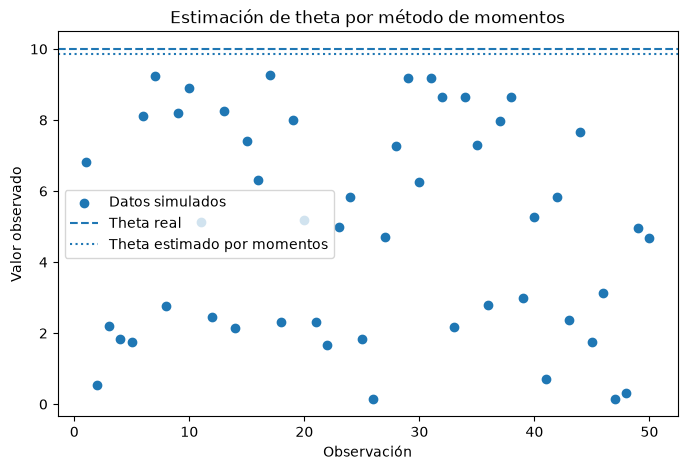

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(range(1, n + 1), muestra_uniforme, label="Datos simulados")
plt.axhline(theta_real, linestyle="--", label="Theta real")
plt.axhline(theta_mm, linestyle=":", label="Theta estimado por momentos")
plt.title("Estimación de theta por método de momentos")
plt.xlabel("Observación")
plt.ylabel("Valor observado")
plt.legend()
plt.show()

**Interpretación.** El estimador $\hat{\theta}_{MM}=2\bar{X}$ usa la media observada para aproximar el límite superior de la distribución uniforme. Como la muestra es aleatoria, la estimación puede quedar por arriba o por debajo del valor real, pero debería acercarse cuando aumenta el tamaño de muestra.

## 1.3 Estimación por máxima verosimilitud (EMV)

La **estimación por máxima verosimilitud** busca el valor del parámetro que hace más probable haber observado la muestra obtenida.

Si $X_1, X_2, \ldots, X_n$ tienen función de densidad o de probabilidad $f(x;\theta)$, la función de verosimilitud se define como:

$$
L(\theta)=\prod_{i=1}^{n} f(x_i;\theta).
$$

El estimador de máxima verosimilitud es el valor que maximiza esa función:

$$
\hat{\theta}_{EMV}=\arg\max_{\theta} L(\theta).
$$

En la práctica se suele maximizar el logaritmo de la verosimilitud porque transforma productos en sumas y simplifica los cálculos.

### Ejemplo EMV: distribución exponencial

Supongamos que la vida útil de ciertos focos sigue una distribución exponencial con tasa $\lambda$:

$$
f(x;\lambda)=\lambda e^{-\lambda x}, \quad x\geq 0.
$$

Para una muestra $x_1,x_2,\ldots,x_n$, el estimador de máxima verosimilitud de $\lambda$ es:

$$
\hat{\lambda}_{EMV}=\frac{1}{\bar{X}}.
$$

Esto significa que la tasa estimada de ocurrencia del evento se obtiene como el inverso del promedio observado.

In [27]:
# Datos de vida útil de focos, en años
datos_focos = np.array([2, 3, 1, 3, 5])

n_focos = len(datos_focos)
media_focos = np.mean(datos_focos)
lambda_emv = 1 / media_focos
vida_media_estimada = 1 / lambda_emv

print(f"Número de focos observados: {n_focos}")
print(f"Media muestral: {media_focos:.4f} años")
print(f"Estimador EMV de lambda: {lambda_emv:.4f} fallas por año")
print(f"Vida media estimada: {vida_media_estimada:.4f} años")

Número de focos observados: 5
Media muestral: 2.8000 años
Estimador EMV de lambda: 0.3571 fallas por año
Vida media estimada: 2.8000 años


A continuación se compara el histograma de los datos con la densidad exponencial usando el parámetro estimado.

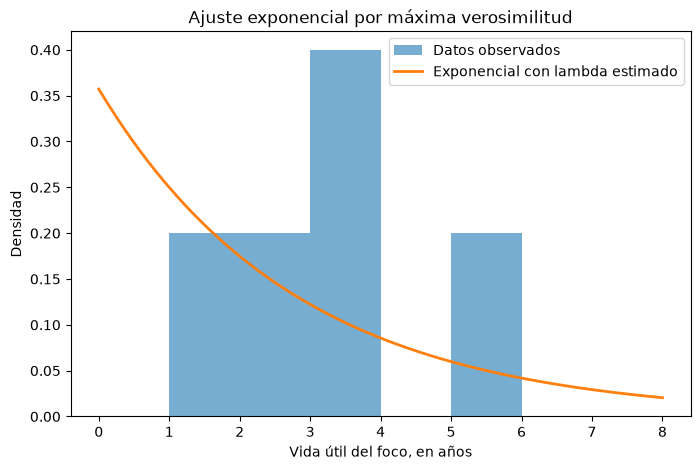

In [28]:
x = np.linspace(0, 8, 200)
densidad_exponencial = lambda_emv * np.exp(-lambda_emv * x)

plt.figure(figsize=(8, 5))
plt.hist(datos_focos, bins=np.arange(0, 8, 1), density=True, alpha=0.6, label="Datos observados")
plt.plot(x, densidad_exponencial, linewidth=2, label="Exponencial con lambda estimado")
plt.title("Ajuste exponencial por máxima verosimilitud")
plt.xlabel("Vida útil del foco, en años")
plt.ylabel("Densidad")
plt.legend()
plt.show()

**Interpretación.** Con estos datos, la tasa estimada es aproximadamente $0.3571$ fallas por año. Esto equivale a una vida media estimada de $2.8$ años. En términos prácticos, el EMV eligió la tasa exponencial que mejor explica las vidas útiles observadas.

## 1.4 Comparación con Python: método de momentos y EMV

Algunos parámetros pueden estimarse por distintos métodos. Para $X\sim U(0,\theta)$:

- Por método de momentos: $\hat{\theta}_{MM}=2\bar{X}$.
- Por máxima verosimilitud: $\hat{\theta}_{EMV}=\max(X_1,\ldots,X_n)$.

El EMV en este caso toma el dato más grande como estimación del límite superior, porque todos los datos deben estar dentro del intervalo $[0,\theta]$.

In [29]:
# Simulación repetida para comparar dos estimadores de theta en U(0, theta)
theta_real = 10
n = 30
repeticiones = 5000

estimadores_mm = []
estimadores_emv = []

for _ in range(repeticiones):
    muestra = rng.uniform(0, theta_real, size=n)
    estimadores_mm.append(2 * np.mean(muestra))
    estimadores_emv.append(np.max(muestra))

estimadores_mm = np.array(estimadores_mm)
estimadores_emv = np.array(estimadores_emv)

comparacion_estimadores = pd.DataFrame({
    "Estimador": ["Método de momentos", "Máxima verosimilitud"],
    "Promedio de estimaciones": [np.mean(estimadores_mm), np.mean(estimadores_emv)],
    "Varianza de estimaciones": [np.var(estimadores_mm, ddof=1), np.var(estimadores_emv, ddof=1)],
    "Sesgo aproximado": [np.mean(estimadores_mm) - theta_real, np.mean(estimadores_emv) - theta_real]
})

comparacion_estimadores

,Estimador,Promedio de estimaciones,Varianza de estimaciones,Sesgo aproximado
0,Método de momentos,10.017414,1.169559,0.017414
1,Máxima verosimilitud,9.679152,0.096129,-0.320848


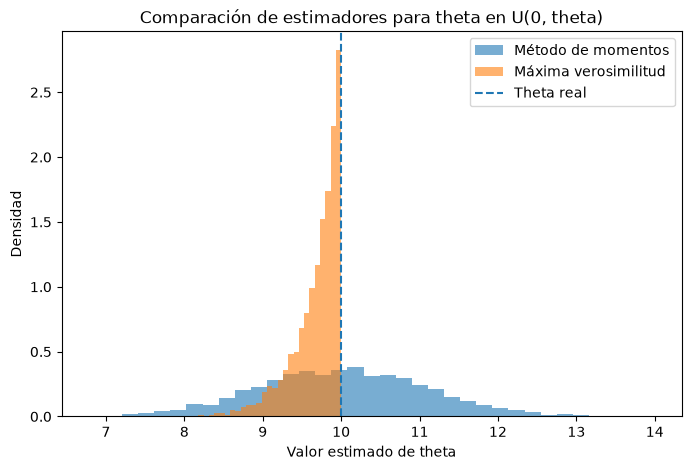

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(estimadores_mm, bins=35, alpha=0.6, density=True, label="Método de momentos")
plt.hist(estimadores_emv, bins=35, alpha=0.6, density=True, label="Máxima verosimilitud")
plt.axvline(theta_real, linestyle="--", label="Theta real")
plt.title("Comparación de estimadores para theta en U(0, theta)")
plt.xlabel("Valor estimado de theta")
plt.ylabel("Densidad")
plt.legend()
plt.show()

**Interpretación.** Ambos estimadores buscan aproximar el mismo parámetro, pero no se comportan igual. El método de momentos se centra alrededor del valor real, mientras que el EMV basado en el máximo tiende a quedar por debajo del verdadero $\theta$ porque, en una muestra finita, es poco probable observar exactamente el límite superior.

# 2. Propiedades de los estimadores

Los estimadores no solo se eligen por facilidad de cálculo. También se evalúan por sus propiedades. Tres propiedades fundamentales son:

- **Insesgadez**.
- **Consistencia**.
- **Eficiencia**.

Estas propiedades ayudan a decidir si un estimador es adecuado para inferir un parámetro poblacional.

## 2.1 Insesgadez

Un estimador es **insesgado** si, en promedio, estima correctamente el parámetro poblacional.

Formalmente, $\hat{\theta}$ es insesgado para $\theta$ si:

$$
\mathbb{E}(\hat{\theta})=\theta.
$$

La interpretación es que, aunque en una muestra particular el estimador puede equivocarse, si repitiéramos el muestreo muchas veces, el promedio de las estimaciones coincidiría con el parámetro verdadero.

### Simulación de insesgadez: media muestral

La media muestral $\bar{X}$ es un estimador insesgado de la media poblacional $\mu$. Para verlo, simulamos muchas muestras de una población normal y calculamos la media de cada muestra.

In [31]:
mu_real = 50
sigma_real = 10
n = 25
repeticiones = 10000

medias_muestrales = []

for _ in range(repeticiones):
    muestra = rng.normal(mu_real, sigma_real, size=n)
    medias_muestrales.append(np.mean(muestra))

medias_muestrales = np.array(medias_muestrales)

print(f"Media real poblacional: {mu_real}")
print(f"Promedio de medias muestrales simuladas: {np.mean(medias_muestrales):.4f}")
print(f"Sesgo aproximado: {np.mean(medias_muestrales) - mu_real:.4f}")

Media real poblacional: 50
Promedio de medias muestrales simuladas: 49.9962
Sesgo aproximado: -0.0038


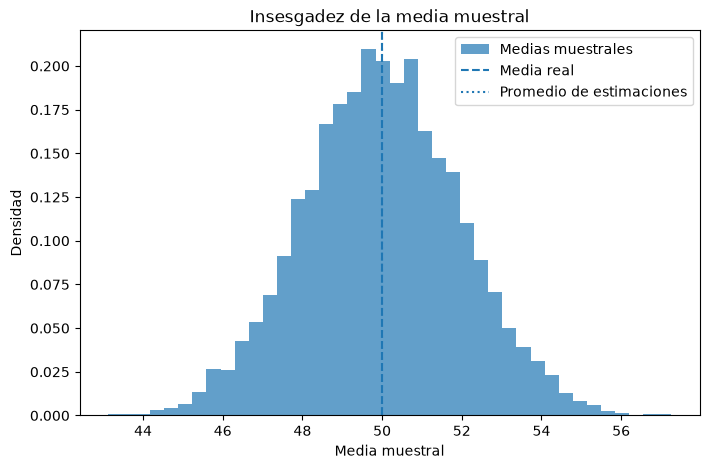

In [32]:
plt.figure(figsize=(8, 5))
plt.hist(medias_muestrales, bins=40, density=True, alpha=0.7, label="Medias muestrales")
plt.axvline(mu_real, linestyle="--", label="Media real")
plt.axvline(np.mean(medias_muestrales), linestyle=":", label="Promedio de estimaciones")
plt.title("Insesgadez de la media muestral")
plt.xlabel("Media muestral")
plt.ylabel("Densidad")
plt.legend()
plt.show()

**Interpretación.** El promedio de las medias muestrales simuladas queda muy cerca de la media real. Esto ilustra la insesgadez: el estimador no se desvía sistemáticamente hacia arriba ni hacia abajo.

## 2.2 Consistencia

Un estimador es **consistente** si se aproxima cada vez más al parámetro verdadero cuando el tamaño de la muestra aumenta.

En términos intuitivos, un estimador consistente mejora al tener más información. Si se recolectan más datos, la estimación debería estabilizarse cerca del valor real.

### Simulación de consistencia: media muestral

Para observar la consistencia, simulamos muestras de diferentes tamaños y calculamos el error absoluto promedio de la media muestral respecto a la media real.

In [33]:
mu_real = 100
sigma_real = 15
n_valores = np.array([5, 10, 20, 50, 100, 300, 500, 1000])
repeticiones = 3000

errores_promedio = []

for n in n_valores:
    errores = []
    for _ in range(repeticiones):
        muestra = rng.normal(mu_real, sigma_real, size=n)
        media_estimada = np.mean(muestra)
        errores.append(abs(media_estimada - mu_real))
    errores_promedio.append(np.mean(errores))

errores_promedio = np.array(errores_promedio)

pd.DataFrame({
    "Tamaño de muestra": n_valores,
    "Error absoluto promedio": errores_promedio
})

,Tamaño de muestra,Error absoluto promedio
0,5,5.464473
1,10,3.724668
2,20,2.697114
3,50,1.712077
4,100,1.222420
5,300,0.690386
6,500,0.536603
7,1000,0.373872


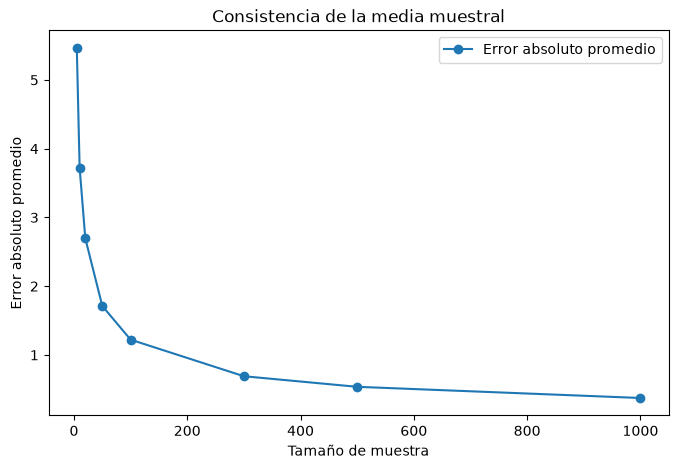

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(n_valores, errores_promedio, marker="o", label="Error absoluto promedio")
plt.title("Consistencia de la media muestral")
plt.xlabel("Tamaño de muestra")
plt.ylabel("Error absoluto promedio")
plt.legend()
plt.show()

**Interpretación.** Al aumentar el tamaño de muestra, el error promedio disminuye. Esto muestra que la media muestral se acerca al valor real cuando se dispone de más observaciones.

## 2.3 Eficiencia

La **eficiencia** compara estimadores que buscan estimar el mismo parámetro. Un estimador es más eficiente que otro si tiene menor variabilidad, suponiendo que ambos sean comparables y, en particular, si ambos son insesgados.

La interpretación práctica es que un estimador eficiente produce estimaciones más estables de una muestra a otra.

### Simulación de eficiencia: media muestral vs mediana muestral

Para datos normales, tanto la media como la mediana pueden usarse para estimar el centro de la distribución. Sin embargo, la media suele ser más eficiente porque presenta menor varianza muestral como estimador de $\mu$.

In [35]:
mu_real = 0
sigma_real = 1
n = 40
repeticiones = 8000

estimaciones_media = []
estimaciones_mediana = []

for _ in range(repeticiones):
    muestra = rng.normal(mu_real, sigma_real, size=n)
    estimaciones_media.append(np.mean(muestra))
    estimaciones_mediana.append(np.median(muestra))

estimaciones_media = np.array(estimaciones_media)
estimaciones_mediana = np.array(estimaciones_mediana)

var_media = np.var(estimaciones_media, ddof=1)
var_mediana = np.var(estimaciones_mediana, ddof=1)

pd.DataFrame({
    "Estimador": ["Media muestral", "Mediana muestral"],
    "Promedio de estimaciones": [np.mean(estimaciones_media), np.mean(estimaciones_mediana)],
    "Varianza de estimaciones": [var_media, var_mediana]
})

,Estimador,Promedio de estimaciones,Varianza de estimaciones
0,Media muestral,-0.000118,0.025063
1,Mediana muestral,-0.000907,0.037563


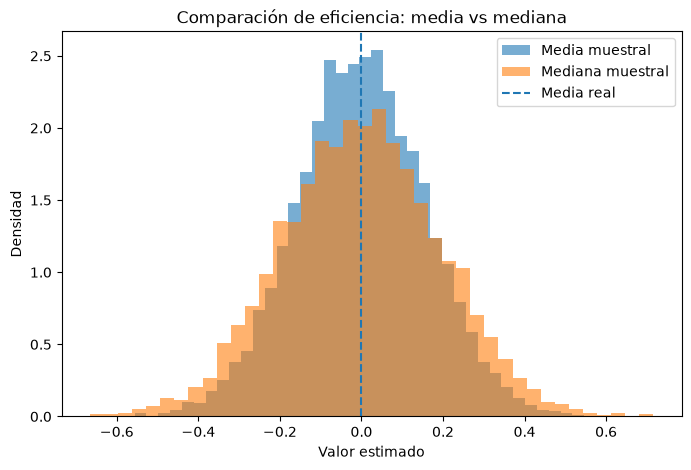

In [36]:
plt.figure(figsize=(8, 5))
plt.hist(estimaciones_media, bins=40, alpha=0.6, density=True, label="Media muestral")
plt.hist(estimaciones_mediana, bins=40, alpha=0.6, density=True, label="Mediana muestral")
plt.axvline(mu_real, linestyle="--", label="Media real")
plt.title("Comparación de eficiencia: media vs mediana")
plt.xlabel("Valor estimado")
plt.ylabel("Densidad")
plt.legend()
plt.show()

**Interpretación.** Las dos distribuciones de estimaciones se concentran cerca del valor real, pero la media muestral tiene menor varianza. En este escenario, la media es más eficiente para estimar el centro de una población normal.

# 3. Intervalos de confianza

Un **intervalo de confianza** es un rango construido a partir de una muestra que busca contener el parámetro poblacional con cierto nivel de confianza.

Por ejemplo, un intervalo de confianza del 95% no significa que el parámetro tenga 95% de probabilidad de estar en un intervalo ya calculado. La interpretación frecuentista es que, si repitiéramos el procedimiento muchas veces, aproximadamente el 95% de los intervalos construidos contendrían al parámetro verdadero.

## 3.1 Intervalo de confianza para una media con $\sigma$ desconocida: t de Student

Cuando se desea estimar una media poblacional y la desviación estándar poblacional $\sigma$ es desconocida, se usa la desviación estándar muestral $s$ y la distribución t de Student.

El intervalo de confianza para $\mu$ es:

$$
\bar{x}\pm t_{\alpha/2,n-1}\frac{s}{\sqrt{n}}.
$$

Donde:

- $\bar{x}$ es la media muestral.
- $s$ es la desviación estándar muestral.
- $n$ es el tamaño de muestra.
- $t_{\alpha/2,n-1}$ es el valor crítico de la distribución t con $n-1$ grados de libertad.

### Ejemplo: intervalo para el tiempo promedio de atención

Supongamos que se mide el tiempo de atención de 15 solicitudes. Queremos estimar el tiempo promedio poblacional con un nivel de confianza del 95%.

In [37]:
tiempos = np.array([12.5, 13.1, 11.8, 14.0, 12.9, 13.5, 15.2, 12.7, 13.8, 14.1, 12.2, 13.4, 14.5, 13.0, 12.8])

n = len(tiempos)
media = np.mean(tiempos)
s = np.std(tiempos, ddof=1)
confianza = 0.95
alpha = 1 - confianza

t_critico = stats.t.ppf(1 - alpha / 2, df=n - 1)
error_estandar = s / np.sqrt(n)
margen_error = t_critico * error_estandar

limite_inferior = media - margen_error
limite_superior = media + margen_error

print(f"Media muestral: {media:.4f}")
print(f"Desviación estándar muestral: {s:.4f}")
print(f"Valor crítico t: {t_critico:.4f}")
print(f"Intervalo de confianza del 95%: ({limite_inferior:.4f}, {limite_superior:.4f})")

Media muestral: 13.3000
Desviación estándar muestral: 0.9055
Valor crítico t: 2.1448
Intervalo de confianza del 95%: (12.7985, 13.8015)


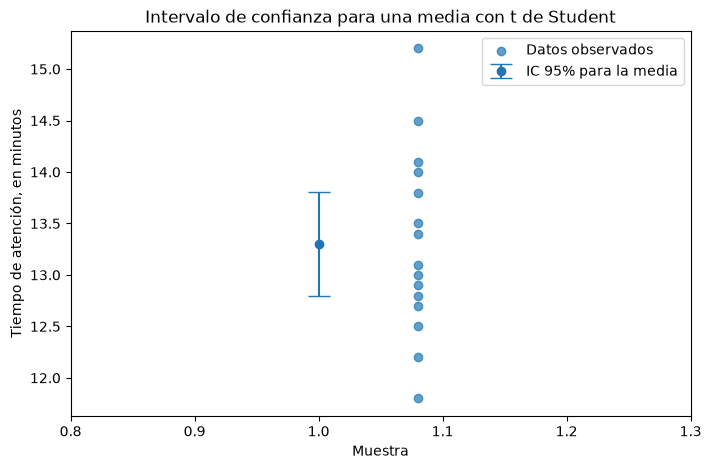

In [38]:
plt.figure(figsize=(8, 5))
plt.errorbar(x=[1], y=[media], yerr=[[media - limite_inferior], [limite_superior - media]], fmt="o", capsize=8, label="IC 95% para la media")
plt.scatter(np.ones_like(tiempos) * 1.08, tiempos, alpha=0.7, label="Datos observados")
plt.title("Intervalo de confianza para una media con t de Student")
plt.xlabel("Muestra")
plt.ylabel("Tiempo de atención, en minutos")
plt.xlim(0.8, 1.3)
plt.legend()
plt.show()

**Interpretación del intervalo.** Con un 95% de confianza, el tiempo promedio poblacional de atención se estima entre los límites calculados. Esto no garantiza que el parámetro esté dentro del intervalo específico, sino que el método usado tiene una confiabilidad del 95% en repeticiones sucesivas.

## 3.2 Intervalo de confianza para una media con $\sigma$ conocida: distribución normal

Cuando la desviación estándar poblacional $\sigma$ es conocida o el tamaño de muestra es suficientemente grande, puede usarse la distribución normal estándar.

El intervalo de confianza para $\mu$ es:

$$
\bar{x}\pm z_{\alpha/2}\frac{\sigma}{\sqrt{n}}.
$$

### Ejemplo: media con desviación estándar poblacional conocida

Supongamos que una máquina llena bolsas de producto. Se sabe por especificación histórica que la desviación estándar poblacional es $\sigma=3$ gramos. Se toma una muestra de 40 bolsas para estimar el peso promedio.

In [39]:
pesos = rng.normal(loc=500, scale=3, size=40)

sigma_conocida = 3
n = len(pesos)
media_pesos = np.mean(pesos)
confianza = 0.95
alpha = 1 - confianza

z_critico = stats.norm.ppf(1 - alpha / 2)
error_estandar_normal = sigma_conocida / np.sqrt(n)
margen_error_normal = z_critico * error_estandar_normal

li_normal = media_pesos - margen_error_normal
ls_normal = media_pesos + margen_error_normal

print(f"Media muestral: {media_pesos:.4f} gramos")
print(f"Valor crítico z: {z_critico:.4f}")
print(f"Intervalo de confianza del 95%: ({li_normal:.4f}, {ls_normal:.4f}) gramos")

Media muestral: 499.0065 gramos
Valor crítico z: 1.9600
Intervalo de confianza del 95%: (498.0768, 499.9362) gramos


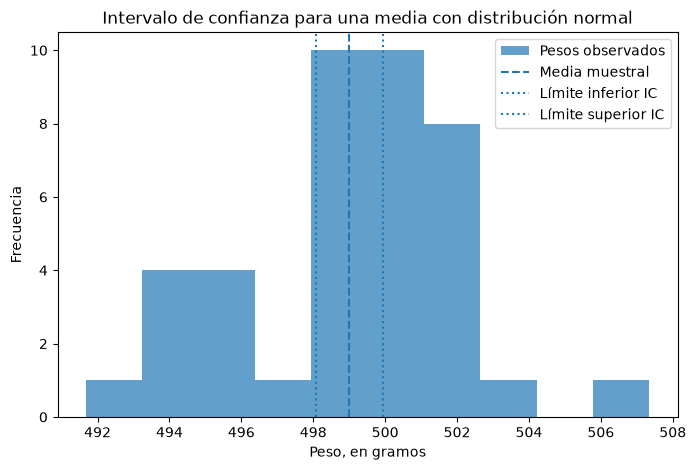

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(pesos, bins=10, alpha=0.7, label="Pesos observados")
plt.axvline(media_pesos, linestyle="--", label="Media muestral")
plt.axvline(li_normal, linestyle=":", label="Límite inferior IC")
plt.axvline(ls_normal, linestyle=":", label="Límite superior IC")
plt.title("Intervalo de confianza para una media con distribución normal")
plt.xlabel("Peso, en gramos")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

**Interpretación del intervalo.** Con un 95% de confianza, el peso promedio poblacional se encuentra entre los límites calculados por el método normal, usando la desviación estándar poblacional conocida.

## 3.3 Intervalo de confianza para una proporción

Cuando se estudia una proporción poblacional $p$, se usa la proporción muestral:

$$
\hat{p}=\frac{x}{n},
$$

donde $x$ es el número de éxitos observados y $n$ es el tamaño de muestra.

Para muestras suficientemente grandes, un intervalo aproximado de confianza para $p$ es:

$$
\hat{p}\pm z_{\alpha/2}\sqrt{\frac{\hat{p}(1-\hat{p})}{n}}.
$$

### Ejemplo: intervalo para proporción de aprobación

Supongamos que se encuestan 200 personas y 124 aprueban cierto servicio. Se quiere estimar la proporción poblacional de aprobación con un 95% de confianza.

In [41]:
n = 200
exitos = 124
p_hat = exitos / n
confianza = 0.95
alpha = 1 - confianza

z_critico = stats.norm.ppf(1 - alpha / 2)
error_estandar_p = np.sqrt(p_hat * (1 - p_hat) / n)
margen_error_p = z_critico * error_estandar_p

li_p = p_hat - margen_error_p
ls_p = p_hat + margen_error_p

print(f"Proporción muestral: {p_hat:.4f}")
print(f"Intervalo de confianza del 95% para p: ({li_p:.4f}, {ls_p:.4f})")

Proporción muestral: 0.6200
Intervalo de confianza del 95% para p: (0.5527, 0.6873)


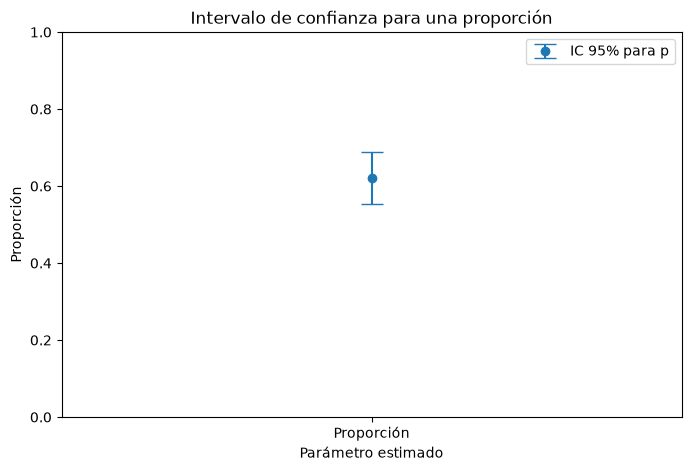

In [42]:
plt.figure(figsize=(8, 5))
plt.errorbar(x=["Proporción"], y=[p_hat], yerr=[[p_hat - li_p], [ls_p - p_hat]], fmt="o", capsize=8, label="IC 95% para p")
plt.ylim(0, 1)
plt.title("Intervalo de confianza para una proporción")
plt.xlabel("Parámetro estimado")
plt.ylabel("Proporción")
plt.legend()
plt.show()

**Interpretación del intervalo.** Con un 95% de confianza, la proporción poblacional de aprobación se estima entre los límites calculados. Es decir, el procedimiento indica un rango plausible para el porcentaje real de aprobación en la población.

## 3.4 Comparación visual: varios intervalos de confianza

Para reforzar la interpretación frecuentista, simulamos muchas muestras de una población con media conocida. Calculamos un intervalo de confianza para cada muestra y observamos cuántos intervalos contienen la media real.

In [43]:
mu_real = 20
sigma_real = 4
n = 30
repeticiones = 100
confianza = 0.95
alpha = 1 - confianza

intervalos = []
contiene_mu = []

for _ in range(repeticiones):
    muestra = rng.normal(mu_real, sigma_real, size=n)
    media_m = np.mean(muestra)
    s_m = np.std(muestra, ddof=1)
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margen = t_crit * s_m / np.sqrt(n)
    li = media_m - margen
    ls = media_m + margen
    intervalos.append((li, ls, media_m))
    contiene_mu.append(li <= mu_real <= ls)

contiene_mu = np.array(contiene_mu)
proporcion_cobertura = np.mean(contiene_mu)

print(f"Proporción de intervalos que contienen la media real: {proporcion_cobertura:.4f}")

Proporción de intervalos que contienen la media real: 0.9800


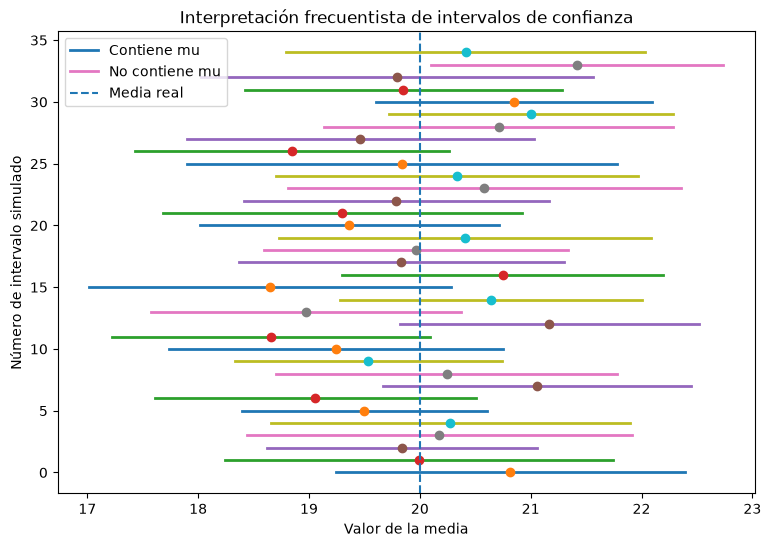

In [44]:
plt.figure(figsize=(9, 6))

# Se grafican solo los primeros 35 intervalos para mantener claridad visual
for i, (li, ls, media_m) in enumerate(intervalos[:35]):
    etiqueta = "Contiene mu" if contiene_mu[i] else "No contiene mu"
    plt.plot([li, ls], [i, i], linewidth=2, label=etiqueta if etiqueta not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.plot(media_m, i, marker="o")

plt.axvline(mu_real, linestyle="--", label="Media real")
plt.title("Interpretación frecuentista de intervalos de confianza")
plt.xlabel("Valor de la media")
plt.ylabel("Número de intervalo simulado")
plt.legend()
plt.show()

**Interpretación.** La mayoría de los intervalos contienen la media real, pero algunos no. Esto es consistente con la idea de un intervalo al 95%: el procedimiento está diseñado para capturar el parámetro en aproximadamente el 95% de las repeticiones, no necesariamente en todas.

# 4. Conclusión

En este notebook se estudiaron los elementos centrales de la estadística inferencial relacionados con estimadores e intervalos de confianza.

Los **estimadores** permiten usar datos muestrales para aproximar parámetros poblacionales desconocidos. El **método de momentos** estima parámetros igualando momentos teóricos con momentos muestrales, mientras que la **estimación por máxima verosimilitud** selecciona el valor del parámetro que hace más probable la muestra observada.

También se revisaron tres propiedades importantes. La **insesgadez** indica que un estimador acierta en promedio; la **consistencia** muestra que el estimador mejora al aumentar el tamaño de muestra; y la **eficiencia** permite comparar estimadores según su variabilidad.

Finalmente, los **intervalos de confianza** proporcionan rangos plausibles para parámetros poblacionales, como una media o una proporción. Su interpretación correcta es fundamental: un intervalo de confianza no garantiza que el parámetro esté dentro del intervalo calculado, sino que el procedimiento utilizado tiene una frecuencia de acierto determinada en muestreos repetidos.

En conjunto, estos conceptos permiten conectar los datos observados con conclusiones estadísticas razonables sobre una población.

# 5. Bibliografía

- Rincón, L. **Curso elemental de probabilidad y estadística**. Universidad Nacional Autónoma de México.
- Ross, S. M. **A First Course in Probability**. Pearson.
- Ross, S. M. **Introduction to Probability and Statistics for Engineers and Scientists**. Academic Press.
- Mood, A. M., Graybill, F. A., & Boes, D. C. **Introduction to the Theory of Statistics**. McGraw-Hill.
- Mendenhall, W., Beaver, R. J., & Beaver, B. M. **Introduction to Probability and Statistics**. Cengage Learning.